# Analyze Log Model 

In [1]:
import sys 
import pickle 
import pandas as pd
import os 

from pathlib import Path
from sklearn.metrics import classification_report, mean_squared_error, r2_score, balanced_accuracy_score, confusion_matrix
from scipy.stats import spearmanr

# Import project modules
PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))
sys.path.append(str(PROJECT_ROOT / 'code' / '02_train'))  
from config import paths 

from util.charts import * 
from train_log_model import LogModel


# Output path for results 
OUT_PATH = paths.RESULTS / 'model_analysis' / 'log'

# Ordered mapping for all 9 fine bands

FINE_BINS = [0, 5000, 10000, 15000, 30000, 50000, 100000, 200000, 300000, float('inf')]
FINE_BINS_LABELS = ['0-5k', '5k-10k', '10k-15k', '15k-30k', '30k-50k', '50k-100k', '100k-200k', '200k-300k', '300k+']

FINE_BAND_ORDER = {
    '0-5k': 0, '5k-10k': 1, '10k-15k': 2,
    '15k-30k': 3, '30k-50k': 4, '50k-100k': 5,
    '100k-200k': 6, '200k-300k': 7, '300k+': 8
}

### Load models

In [2]:
models = {}
for model in os.listdir(paths.MODELS) : 
    if ('ibs' not in model) and ('kchs' not in model) and ('DS_Store' not in model) : 
        with open(paths.MODELS / model, 'rb') as f : 
            model_file = pickle.load(f)

        print(f"Loaded {model_file.name}.")

        models[model_file.name] = model_file 

Loaded parent_model_all_vars.
Loaded low_income_model.
Loaded middle_income_model.
Loaded high_income_model.
Loaded parent_model_adjusted.


#### Load log model validation set

In [3]:
validation_df = pd.read_csv(paths.PROCESSED_DATA / 'kchs_2021_validation_log.csv', index_col='hhid')

validation_df.head()

,household_size,mm_age,prop_over65,prop_under5,prop_m1864,prop_w1864,nr_rooms,county_bomet,county_bungoma,county_busia,...,occupation_public_sector_worker,occupation_retired,total_expenditure_adjusted,urban_rural_classification_Urban,coarse_band,fine_band,coarse_pred_all_vars,fine_pred_all_vars,coarse_pred_adjusted,fine_pred_adjusted
hhid,,,,,,,,,,,,,,,,,,,,,
16845.0,6.0,5.225747,0.00,0.166667,0.166667,0.666667,2,0,0,0,...,0,1,38016.463262,1,Middle income,30k-50k,Middle income,30k-50k,Middle income,30k-50k
702.0,5.0,5.153292,0.40,0.000000,0.000000,0.000000,3,0,0,0,...,0,1,43681.868984,1,Middle income,30k-50k,Middle income,15k-30k,Middle income,15k-30k
13927.0,6.0,5.252273,0.00,0.000000,0.333333,0.166667,4,0,0,1,...,0,0,32974.528770,0,Middle income,30k-50k,Middle income,15k-30k,Middle income,15k-30k
11772.0,1.0,3.912023,0.00,0.000000,1.000000,0.000000,1,0,0,0,...,0,0,9628.794024,1,Low income,5k-10k,Low income,10k-15k,Low income,10k-15k
16185.0,4.0,5.141664,0.25,0.250000,0.000000,0.500000,3,0,0,0,...,0,0,36545.779371,1,Middle income,30k-50k,Middle income,15k-30k,Middle income,15k-30k


#### Run Post Prediction Decision Rules 

In [4]:
def adjust_nairobi_mobassa(row : pd.Series) -> str : 
    if (row['fine_pred_adjusted'] == '10k-15k') and ((row['county_mombasa'] == 1) or (row['county_nairobi'] == 1)) : 
        row['fine_pred_adjusted'] = '5k-10k'
    
    return row['fine_pred_adjusted']

def adjust_hhead_working(row : pd.Series) -> str : 
    if row['fine_pred_adjusted'] == '0-5k' : 
        return row['fine_pred_adjusted']
    
    elif (row['working_yes'] == 0) or (row['occupation_housewife'] == 1) or (row['occupation_retired'] == 1) : 
        return "5k-10k"
    
    return row['fine_pred_adjusted']

before = validation_df['fine_pred_adjusted'].copy()

# Household head not working 
validation_df['fine_pred_adjusted'] = validation_df.apply(adjust_hhead_working, axis=1)

# Nairobi and Mombassa Poor 
validation_df["fine_pred_adjusted"] = validation_df.apply(adjust_nairobi_mobassa, axis=1)

# Rederive coarse band from updated fine prediction
validation_df['coarse_pred_adjusted'] = validation_df['fine_pred_adjusted'].map(FINE_BAND_ORDER).apply(
    lambda b: 'Low income' if b <= 2 else 'Middle income' if b <= 5 else 'High income'
)

print(f"Post-prediction rules changed {(validation_df['fine_pred_adjusted'] != before).sum():,} predictions")

Post-prediction rules changed 329 predictions


#### Load OLS model validation dataset 

In [5]:
def calculate_adjusted_hh_income(row : pd.Series, kes_col : str) -> float : 
    return (
        row[kes_col]
        * row['pdeflator']
        * row['adq_scale_consumption']
        * inflation
    )

validation_df_ols = pd.read_csv(paths.PROCESSED_DATA / 'kchs_2021_validation.csv', low_memory=False)

# Adjust numbers 
inflation = 1.211
validation_df_ols['Actual_KES_adjusted'] = validation_df_ols.apply(lambda row : calculate_adjusted_hh_income(row, 'Actual_KES'), axis=1)
validation_df_ols['Predicted_KES_adjusted'] = validation_df_ols.apply(lambda row : calculate_adjusted_hh_income(row, 'Predicted_KES'), axis=1)

# Alias to match logit validation df column name
validation_df_ols['total_expenditure_adjusted'] = validation_df_ols['Actual_KES_adjusted']

# Bin into specific bands 
validation_df_ols['fine_band'] = pd.cut(validation_df_ols['Actual_KES_adjusted'], bins=FINE_BINS, labels=FINE_BINS_LABELS, right=True).astype(str)
validation_df_ols['fine_pred_ols'] = pd.cut(validation_df_ols['Predicted_KES_adjusted'], bins=FINE_BINS, labels=FINE_BINS_LABELS, right=True).astype(str)

# Bin into coarse bands 
validation_df_ols['coarse_band'] = validation_df_ols['fine_band'].map(FINE_BAND_ORDER).apply(
    lambda band_num : "Low income" if band_num <= 2 else "Middle income" if band_num <=5 else "High income"
)
validation_df_ols['coarse_pred_ols'] = validation_df_ols['fine_pred_ols'].map(FINE_BAND_ORDER).apply(
    lambda band_num : "Low income" if band_num <= 2 else "Middle income" if band_num <=5 else "High income"
)

validation_df_ols.head(5)

,hhid,Actual,Predicted,Actual_KES,Predicted_KES,Actual_Decile,Actual_Percentile,Predicted_Decile,Predicted_Percentile,log_error,...,actual_consumption_log,Actually_Poor,Predicted_Poor,Actual_KES_adjusted,Predicted_KES_adjusted,total_expenditure_adjusted,fine_band,fine_pred_ols,coarse_band,coarse_pred_ols
0,11472.0,9.843433,9.542311,18834.2680,13937.112583,10,97,10,92,-0.301123,...,9.843433,False,False,66834.258018,49456.478926,66834.258018,50k-100k,30k-50k,Middle income,Middle income
1,16174.0,8.978422,8.836062,7930.1090,6877.856814,8,73,7,66,-0.142360,...,8.978422,False,True,51859.826548,44978.506774,51859.826548,50k-100k,30k-50k,Middle income,Middle income
2,80.0,8.443020,8.511858,4642.5527,4973.395619,5,42,5,46,0.068838,...,8.443020,True,True,18468.836316,19784.983729,18468.836316,15k-30k,15k-30k,Middle income,Middle income
3,169.0,8.734915,8.770913,6216.2065,6444.053950,6,60,7,62,0.035998,...,8.734915,True,True,27047.842819,28039.248431,27047.842819,15k-30k,15k-30k,Middle income,Middle income
4,1005.0,9.490932,9.326391,13239.1230,11230.532121,10,92,9,87,-0.164540,...,9.490932,False,False,58548.830247,49666.017813,58548.830247,50k-100k,30k-50k,Middle income,Middle income


In [6]:
MODELS = [
    (validation_df,     'all',      'All vars', 'fine_pred_all_vars', 'coarse_pred_all_vars'),
    (validation_df,     'adjusted', 'Adjusted', 'fine_pred_adjusted', 'coarse_pred_adjusted'),
    (validation_df_ols, 'ols',      'OLS',      'fine_pred_ols',      'coarse_pred_ols'),
]

In [7]:
def classification_report_model(model: LogModel) -> pd.DataFrame:
    """Return a classification report DataFrame for a fitted LogModel."""
    predicted_probs = model.model.predict(model.X_test)
    y_pred = predicted_probs.idxmax(axis=1)

    report = classification_report(
        model.y_test, y_pred,
        labels=[0, 1, 2],
        target_names=['low', 'middle', 'high'],
        output_dict=True
    )

    print(f"\n{'='*50}")
    print(f"Model: {model.name}")
    print(f"{'='*50}")
    print(classification_report(
        model.y_test, y_pred,
        labels=[0, 1, 2],
        target_names=['low', 'middle', 'high']
    ))

    return pd.DataFrame(report).T

# Save all classification reports to one Excel file, one tab per model
out_file = OUT_PATH / 'classification_reports.xlsx'
with pd.ExcelWriter(out_file, engine='openpyxl') as writer:
    for model in models.values():
        df = classification_report_model(model)
        df.to_excel(writer, sheet_name=model.name)


Model: parent_model_all_vars
              precision    recall  f1-score   support

         low       0.81      0.71      0.76      1148
      middle       0.85      0.91      0.88      2199
        high       0.69      0.48      0.56        46

    accuracy                           0.83      3393
   macro avg       0.78      0.70      0.73      3393
weighted avg       0.83      0.83      0.83      3393


Model: low_income_model
              precision    recall  f1-score   support

         low       0.78      0.53      0.63       175
      middle       0.57      0.59      0.58       419
        high       0.75      0.81      0.78       554

    accuracy                           0.69      1148
   macro avg       0.70      0.64      0.66      1148
weighted avg       0.69      0.69      0.68      1148


Model: middle_income_model
              precision    recall  f1-score   support

         low       0.76      0.87      0.81      1318
      middle       0.48      0.40      0.44   

#### Make Premium Calculations 

In [8]:
def calculate_premium(band : str) -> int : 
    lower_limit = int(band.split('-')[0].split('k')[0] + '000')
    premium = 0.0275 * lower_limit 

    if premium < 300 : 
        premium = 300 
    
    return premium 

for df, model, _, fine_pred_col, _ in MODELS :
    df[f'premium_{model}'] = df[fine_pred_col].apply(calculate_premium)
    df['correct_premium'] = df['fine_band'].apply(calculate_premium)
    df['correct_premium_exact'] = df['total_expenditure_adjusted'] * 0.0275

### Overall Accuracy checks 

#### Create metrics 

In [9]:
CATEGORY_ORDER = ['Low income', 'Middle income', 'High income']

def calculate_prediction_difference(row : pd.Series, prediction_column : str) -> int : 
    true_band = FINE_BAND_ORDER.get(row['fine_band'])
    predicted_band = FINE_BAND_ORDER.get(row[prediction_column])

    return predicted_band - true_band

def label_prediction(difference : int) -> str : 
    if difference == 0 : 
        return "Correct"
    elif difference > 0 : 
        return "Overcharged"
    else : 
        return "Undercharged"

for df, model, _, fine_pred_col, coarse_pred_col in MODELS :
    df[f'coarse_correct_{model}'] = df['coarse_band'] == df[coarse_pred_col]
    df[f'fine_difference_{model}'] = df.apply(
        lambda row, col=fine_pred_col : calculate_prediction_difference(row, col), axis=1
    )
    df[f'fine_result_{model}'] = df[f'fine_difference_{model}'].apply(label_prediction)

#### How many households are placed correctly in the first step? 

In [10]:
def calculate_first_step_results(df, correct_col) : 
    return (
        df
        .groupby(by='coarse_band')[correct_col]
        .agg(Correct = 'sum', Total='count')
        .loc[CATEGORY_ORDER]
        .assign(Pct=lambda df: (df['Correct'] / df['Total'] * 100).round(1))
    )

first_step_results = pd.concat(
    [calculate_first_step_results(df, f'coarse_correct_{model}') for df, model, *_ in MODELS],
    axis=1,
    keys=[label for _, _, label, *_ in MODELS]
)

display(first_step_results)

All vars             Adjusted                 OLS            
               Correct Total   Pct  Correct Total   Pct Correct Total   Pct
coarse_band                                                                
Low income         815  1148  71.0      722  1148  62.9     876  1169  74.9
Middle income     1995  2199  90.7     1745  2199  79.4    1969  2183  90.2
High income         22    46  47.8       12    46  26.1      19    42  45.2

#### How many households are placed correctly in the second step? 

In [11]:
def calculate_second_step_results(df, model):
    result_col = f'fine_result_{model}'
    return (
        df
        .groupby('fine_band')[result_col]
        .value_counts()
        .unstack(fill_value=0)
        [['Correct', 'Overcharged', 'Undercharged']]
        .loc[list(FINE_BAND_ORDER.keys())]
        .assign(Total=lambda df: df.sum(axis=1))
        .assign(Pct=lambda df: (df['Correct'] / df['Total'] * 100).round(1))
    )

second_step_results = pd.concat(
    [calculate_second_step_results(df, model) for df, model, *_ in MODELS],
    axis=1,
    keys=[label for _, _, label, *_ in MODELS]
)

display(second_step_results)

All vars                                      Adjusted  \
fine_result_all  Correct Overcharged Undercharged Total   Pct  Correct   
fine_band                                                                
0-5k                  92          83            0   175  52.6       87   
5k-10k               246         148           25   419  58.7      221   
10k-15k              176         277          101   554  31.8      125   
15k-30k              976         165          177  1318  74.1      833   
30k-50k              248          42          329   619  40.1      227   
50k-100k             104           9          149   262  39.7       99   
100k-200k             19           0           24    43  44.2       10   
200k-300k              0           0            2     2   0.0        0   
300k+                  0           0            1     1   0.0        0   

                                                         OLS              \
fine_result_all Overcharged Undercharged Total   Pct Correct Overcharged   
fine_band                                                                  
0-5k                     88            0   175  49.7      84         109   
5k-10k                  174           24   419  52.7     222         187   
10k-15k                 297          132   554  22.6     205         247   
15k-30k                 154          331  1318  63.2     934         193   
30k-50k                  38          354   619  36.7     300          55   
50k-100k                  6          157   262  37.8     106          10   
100k-200k                 0           33    43  23.3      13           3   
200k-300k                 0            2     2   0.0       0           0   
300k+                     0            1     1   0.0       0           0   

                                          
fine_result_all Undercharged Total   Pct  
fine_band                                 
0-5k                       0   193  43.5  
5k-10k                    33   442  50.2  
10k-15k                   82   534  38.4  
15k-30k                  196  1323  70.6  
30k-50k                  258   613  48.9  
50k-100k                 131   247  42.9  
100k-200k                 21    37  35.1  
200k-300k                  3     3   0.0  
300k+                      2     2   0.0

#### Overall accuracy 

In [12]:
def calculate_overall_accuracy(df, model) : 
    n = len(df)
    correct = (df[f'fine_difference_{model}'] == 0).sum()
    overcharged = (df[f'fine_difference_{model}'] > 0).sum()
    undercharged = (df[f'fine_difference_{model}'] < 0).sum()

    return pd.Series({
        'Correct': correct,
        'Overcharged': overcharged,
        'Undercharged': undercharged,
        'Correct (%)': round(correct / n * 100, 1),
        'Overcharged (%)': round(overcharged / n * 100, 1),
        'Undercharged (%)': round(undercharged / n * 100, 1),
    })

overall_accuracy_results = pd.concat(
    [calculate_overall_accuracy(df, model) for df, model, *_ in MODELS],
    axis=1,
    keys=[label for _, _, label, *_ in MODELS]
)

display(overall_accuracy_results)

,All vars,Adjusted,OLS
Correct,1861.0,1602.0,1864.0
Overcharged,724.0,757.0,804.0
Undercharged,808.0,1034.0,726.0
Correct (%),54.8,47.2,54.9
Overcharged (%),21.3,22.3,23.7
Undercharged (%),23.8,30.5,21.4


#### How many poor households are overcharged

In [13]:
def calculate_poor_overcharged(df, model):
    poor = df[df['coarse_band'] == 'Low income']
    n = len(poor)
    overcharged = poor[poor[f'fine_difference_{model}'] > 0]
    n_over = len(overcharged)

    overcharge_kes = overcharged[f'premium_{model}'] - overcharged['correct_premium_exact']
    overcharge_pct_income = overcharge_kes / overcharged['total_expenditure_adjusted'] * 100


    return pd.Series({
        'Overcharged (%)': round(n_over / n * 100, 1),
        'Avg bands overcharged': round(overcharged[f'fine_difference_{model}'].mean(), 2),
        'Severely overcharged (%)': round((poor[f'fine_difference_{model}'] >= 2).sum() / n * 100, 1),
        'Median overcharge (KES)': round(overcharge_kes.median(), 1),
        'Median overcharge (% income)': round(overcharge_kes.median(), 2),
        'Mean overcharge (% income)': round(overcharge_kes.mean(), 2),
    })

poor_overcharged_results = pd.concat(
    [calculate_poor_overcharged(df, model) for df, model, *_ in MODELS],
    axis=1,
    keys=[label for _, _, label, *_ in MODELS]
)

display(poor_overcharged_results)

,All vars,Adjusted,OLS
Overcharged (%),44.30,48.70,46.40
Avg bands overcharged,1.13,1.28,1.11
Severely overcharged (%),5.90,12.10,5.00
Median overcharge (KES),85.30,105.60,88.60
Median overcharge (% income),85.28,105.55,88.55
Mean overcharge (% income),105.31,123.62,106.54


#### Get sample for scrolly telling 

In [14]:
df = MODELS[1][0]
columns = ["total_expenditure_adjusted", "coarse_band", "fine_band", "coarse_pred_adjusted", "fine_pred_adjusted", "correct_premium", "correct_premium_exact", "premium_adjusted", "coarse_correct_adjusted", "fine_difference_adjusted", "fine_result_adjusted"]

df = validation_df[columns]

df.head(5)

,total_expenditure_adjusted,coarse_band,fine_band,coarse_pred_adjusted,fine_pred_adjusted,correct_premium,correct_premium_exact,premium_adjusted,coarse_correct_adjusted,fine_difference_adjusted,fine_result_adjusted
hhid,,,,,,,,,,,
16845.0,38016.463262,Middle income,30k-50k,Low income,5k-10k,825.0,1045.452740,300.0,False,-3,Undercharged
702.0,43681.868984,Middle income,30k-50k,Low income,5k-10k,825.0,1201.251397,300.0,False,-3,Undercharged
13927.0,32974.528770,Middle income,30k-50k,Middle income,15k-30k,825.0,906.799541,412.5,True,-1,Undercharged
11772.0,9628.794024,Low income,5k-10k,Low income,10k-15k,300.0,264.791836,300.0,True,1,Overcharged
16185.0,36545.779371,Middle income,30k-50k,Middle income,15k-30k,825.0,1005.008933,412.5,True,-1,Undercharged


In [ ]:
# ── Guaranteed households ──────────────────────────────────────────────────

# Rule 1: at least 2 severely overcharged poor (fine_difference >= 2)
g_severe_poor = validation_df[columns][
    (validation_df['coarse_band'] == 'Low income') &
    (validation_df['fine_difference_adjusted'] >= 2)
].sample(n=2, random_state=42)

# Rule 1b: the single most extreme overprediction for a low income household
g_extreme_poor = validation_df[columns][
    validation_df['coarse_band'] == 'Low income'
].nlargest(1, 'fine_difference_adjusted')

# Rule 2+3: all high income (100k+) in sample undercharged >=1 band;
#           at least one by >=2 bands
n_high = max(2, round((validation_df['coarse_band'] == 'High income').sum() / len(validation_df) * 100))

g_high_deep = validation_df[columns][
    (validation_df['coarse_band'] == 'High income') &
    (validation_df['fine_difference_adjusted'] <= -2)
].sample(n=1, random_state=42)

g_high_rest = validation_df[columns][
    (validation_df['coarse_band'] == 'High income') &
    (validation_df['fine_difference_adjusted'] <= -1) &
    (~validation_df.index.isin(g_high_deep.index))
].sample(n=n_high - 1, random_state=42)

# Rule 4: majority (>=70%) of 50k-100k households undercharged >=1 band
n_mid_high = max(2, round((validation_df['fine_band'] == '50k-100k').sum() / len(validation_df) * 100))
n_mid_high_under = round(n_mid_high * 0.7)

g_mid_high = validation_df[columns][
    (validation_df['fine_band'] == '50k-100k') &
    (validation_df['fine_difference_adjusted'] <= -1)
].sample(n=n_mid_high_under, random_state=42)

# Rule 5: at least one household in the 300k+ band
g_300k = validation_df[columns][
    validation_df['fine_band'] == '300k+'
].sample(n=1, random_state=42)

guaranteed = pd.concat([g_severe_poor, g_extreme_poor, g_high_deep, g_high_rest, g_mid_high, g_300k])
guaranteed = guaranteed[~guaranteed.index.duplicated()]  # drop if extreme poor overlaps with severe poor

# ── Stratified sample for remaining slots ──────────────────────────────────
n_remaining = 100 - len(guaranteed)
remaining_pool = validation_df[columns].drop(index=guaranteed.index)

main_sample = (
    remaining_pool
    .groupby(['coarse_band', 'fine_band', 'fine_result_adjusted'], group_keys=False)
    .apply(lambda g: g.sample(
        n=max(1, round(len(g) / len(remaining_pool) * n_remaining)),
        random_state=42
    ))
    .head(n_remaining)
)

sample_100 = pd.concat([guaranteed, main_sample]).sample(frac=1, random_state=42)

# ── Verification ───────────────────────────────────────────────────────────
def compare_outcomes(coarse_label):
    agg = (
        validation_df[validation_df['coarse_band'] == coarse_label]['fine_result_adjusted']
        .value_counts(normalize=True).mul(100).round(1)
    )
    smp = (
        sample_100[sample_100['coarse_band'] == coarse_label]['fine_result_adjusted']
        .value_counts(normalize=True).mul(100).round(1)
    )
    return pd.DataFrame({'Full data': agg, 'Sample': smp})

high_in_sample     = sample_100[sample_100['coarse_band'] == 'High income']
mid_high_in_sample = sample_100[sample_100['fine_band'] == '50k-100k']
low_in_sample      = sample_100[sample_100['coarse_band'] == 'Low income']

print(f"Sample size: {len(sample_100)}")
print(f"\nMax overprediction (low income):        {low_in_sample['fine_difference_adjusted'].max()} bands")
print(f"Severely overcharged poor (diff >= 2):  {(low_in_sample['fine_difference_adjusted'] >= 2).sum()}")
print(f"High income undercharged >= 1 band:     {(high_in_sample['fine_difference_adjusted'] <= -1).sum()} / {len(high_in_sample)}")
print(f"High income undercharged >= 2 bands:    {(high_in_sample['fine_difference_adjusted'] <= -2).sum()} / {len(high_in_sample)}")
print(f"50k-100k undercharged >= 1 band:        {(mid_high_in_sample['fine_difference_adjusted'] <= -1).sum()} / {len(mid_high_in_sample)}")
print(f"300k+ households:                       {(sample_100['fine_band'] == '300k+').sum()}")
print("\nLow income prediction outcomes (%):")
print(compare_outcomes('Low income'))
print("\nMiddle income prediction outcomes (%):")
print(compare_outcomes('Middle income'))
print("\nHigh income prediction outcomes (%):")
print(compare_outcomes('High income'))

# ── Save ───────────────────────────────────────────────────────────────────
SAVE_COLUMNS = [
    "total_expenditure_adjusted", "coarse_band", "fine_band",
    "coarse_pred_adjusted", "fine_pred_adjusted",
    "correct_premium", "correct_premium_exact", "premium_adjusted",
    "coarse_correct_adjusted", "fine_difference_adjusted", "fine_result_adjusted",
]

sample_100[SAVE_COLUMNS].to_csv(OUT_PATH / 'sample_100_adjusted.csv', index=True)
print(f"\nSaved to {OUT_PATH / 'sample_100_adjusted.csv'}")

sample_100[SAVE_COLUMNS]


In [16]:
validation_df.to_excel('test_2.xlsx')

#### Get overcharging stats 

<Axes: >

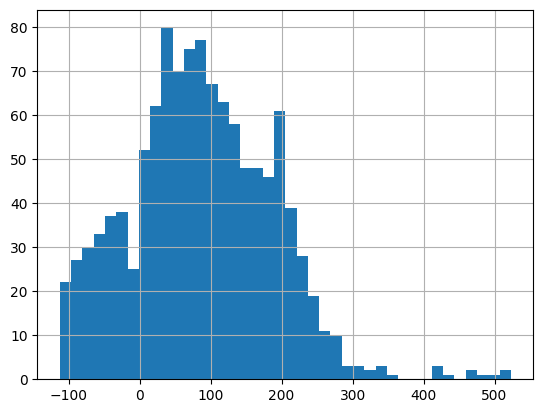

In [17]:
def calculate_poor_overcharge_kes(df, model):
    """Return KES overcharge series for all low-income households (negative = undercharge)."""
    poor = df[df['coarse_band'] == 'Low income']
    return poor[f'premium_{model}'] - poor['correct_premium_exact']

results = calculate_poor_overcharge_kes(MODELS[1][0], MODELS[1][1])
results.hist(bins=40)


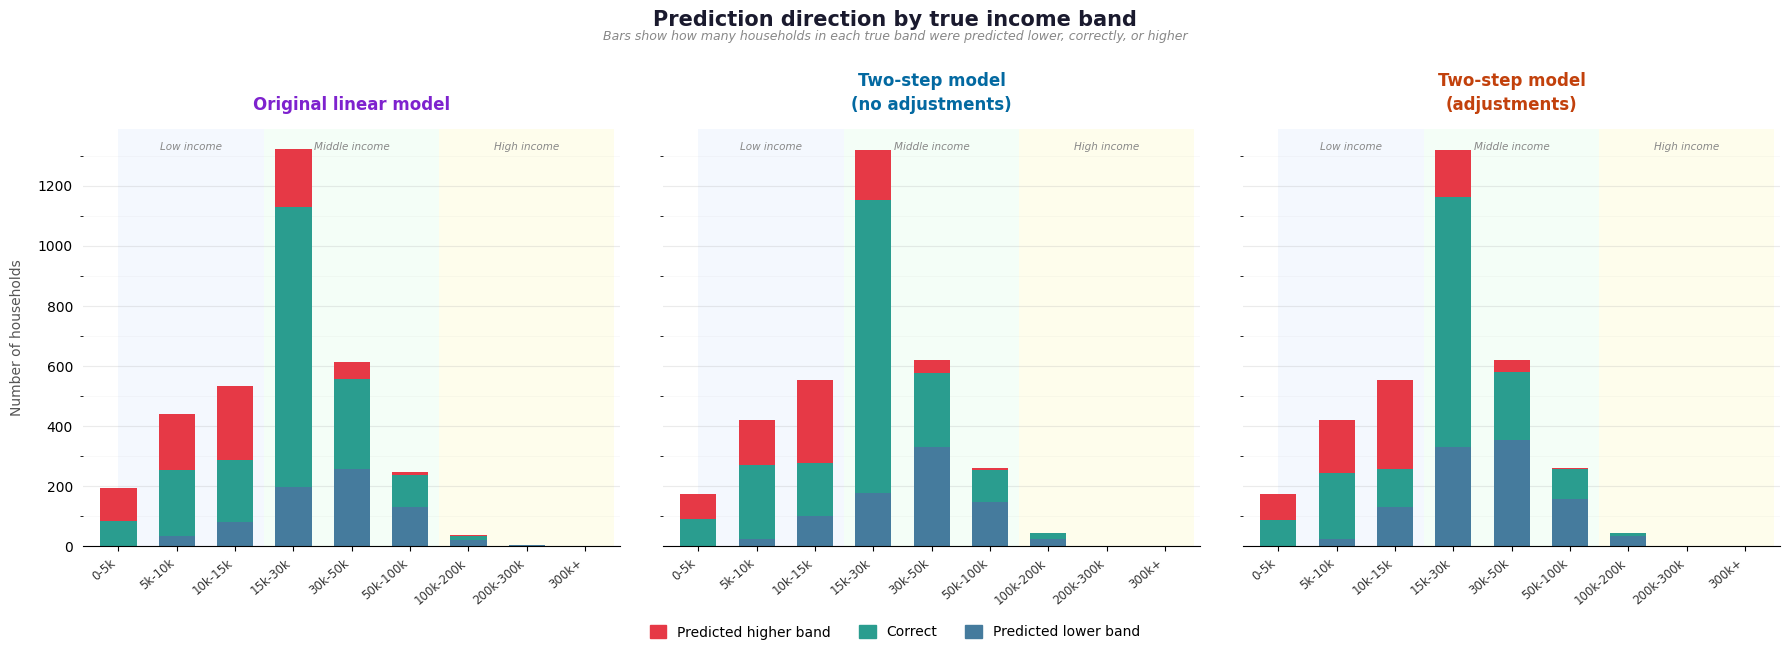

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np

ORDERED_MODELS = [
    (validation_df_ols, 'ols',      'Original linear model'),
    (validation_df,     'all',      'Two-step model\n(no adjustments)'),
    (validation_df,     'adjusted', 'Two-step model\n(adjustments)'),
]

BANDS       = list(FINE_BAND_ORDER.keys())
x           = np.arange(len(BANDS))
BAR_WIDTH   = 0.62

COLOR_OVER  = '#e63946'
COLOR_CORR  = '#2a9d8f'
COLOR_UNDER = '#457b9d'

BAND_REGIONS = [
    (0,   2.5, '#dbeafe', 'Low income'),
    (2.5, 5.5, '#dcfce7', 'Middle income'),
    (5.5, 8.5, '#fef9c3', 'High income'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.patch.set_facecolor('white')

TITLE_COLORS = ['#7e22ce', '#0369a1', '#c2410c']

for ax, (df, model, label), title_color in zip(axes, ORDERED_MODELS, TITLE_COLORS):
    n_over  = np.array([(df[df['fine_band'] == b][f'fine_difference_{model}'] > 0).sum() for b in BANDS])
    n_corr  = np.array([(df[df['fine_band'] == b][f'fine_difference_{model}'] == 0).sum() for b in BANDS])
    n_under = np.array([(df[df['fine_band'] == b][f'fine_difference_{model}'] < 0).sum() for b in BANDS])

    for x0, x1, color, _ in BAND_REGIONS:
        ax.axvspan(x0, x1, color=color, alpha=0.30, zorder=0, lw=0)

    ax.bar(x, n_under, width=BAR_WIDTH, color=COLOR_UNDER, zorder=2)
    ax.bar(x, n_corr,  width=BAR_WIDTH, bottom=n_under,          color=COLOR_CORR,  zorder=2)
    ax.bar(x, n_over,  width=BAR_WIDTH, bottom=n_under + n_corr, color=COLOR_OVER,  zorder=2)

    ax.set_xticks(x)
    ax.set_xticklabels(BANDS, rotation=40, ha='right', fontsize=8.5, color='#333')
    ax.set_title(label, fontsize=12, fontweight='bold', color=title_color,
                 pad=14, linespacing=1.4)
    ax.set_xlim(-0.6, len(BANDS) - 0.4)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(200))
    ax.yaxis.set_minor_locator(mticker.MultipleLocator(100))
    ax.grid(axis='y', which='major', alpha=0.25, lw=0.8, zorder=1)
    ax.grid(axis='y', which='minor', alpha=0.10, lw=0.5, zorder=1)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(left=False, pad=4)
    if ax is axes[0]:
        ax.set_ylabel('Number of households', fontsize=10, color='#555', labelpad=10)

    for x0, x1, _, lbl in BAND_REGIONS:
        ax.text((x0 + x1) / 2, ax.get_ylim()[1] * 0.97, lbl,
                ha='center', va='top', fontsize=7.5, color='#888', style='italic')

bar_handles = [
    mpatches.Patch(color=COLOR_OVER,  label='Predicted higher band'),
    mpatches.Patch(color=COLOR_CORR,  label='Correct'),
    mpatches.Patch(color=COLOR_UNDER, label='Predicted lower band'),
]
fig.legend(handles=bar_handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.05), frameon=False, fontsize=10,
           handlelength=1.2, handleheight=1.0)

fig.suptitle('Prediction direction by true income band',
             fontsize=15, fontweight='bold', color='#1a1a2e', y=1.02)
fig.text(0.5, 0.97,
         'Bars show how many households in each true band were predicted lower, correctly, or higher',
         ha='center', fontsize=9, color='#888', style='italic')

plt.tight_layout(w_pad=3)
plt.savefig(OUT_PATH / 'prediction_direction_by_band.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()


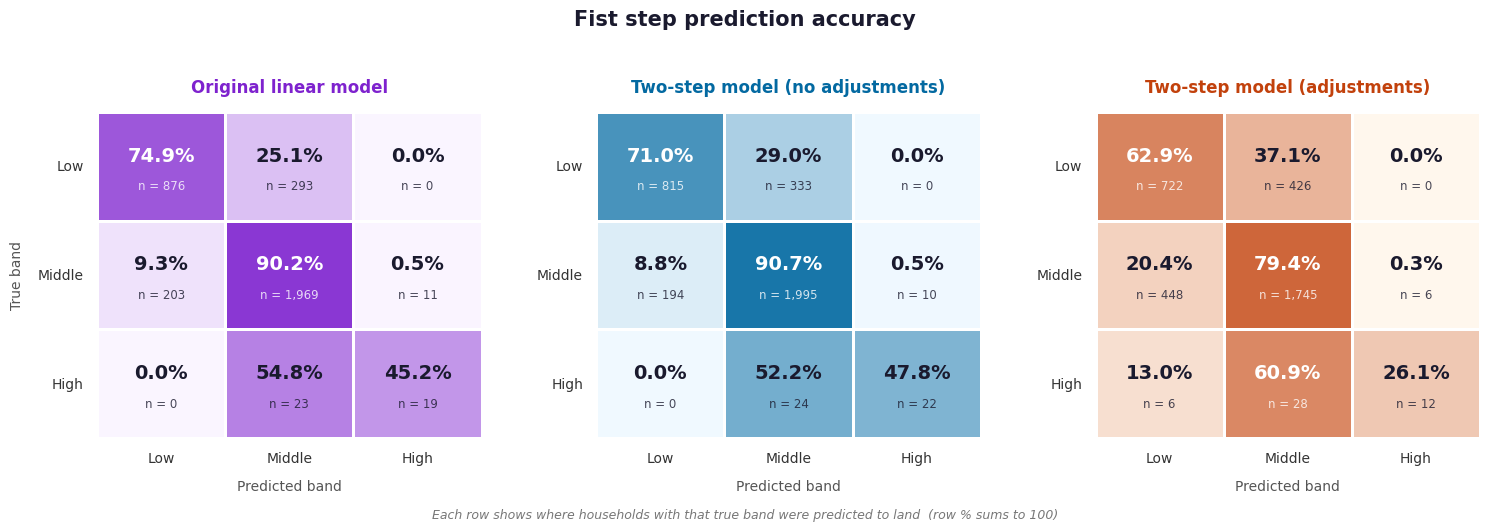

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np

COARSE_ORDER  = ['Low income', 'Middle income', 'High income']
SHORT_LABELS  = ['Low', 'Middle', 'High']

COARSE_MODELS = [
    (validation_df_ols, 'coarse_pred_ols',      'Original linear model'),
    (validation_df,     'coarse_pred_all_vars', 'Two-step model (no adjustments)'),
    (validation_df,     'coarse_pred_adjusted', 'Two-step model (adjustments)'),
]

# Distinct vivid colormap per model
CMAPS = [
    mcolors.LinearSegmentedColormap.from_list('purple', ['#faf5ff', '#7e22ce']),   # vivid purple
    mcolors.LinearSegmentedColormap.from_list('blue',   ['#f0f9ff', '#0369a1']),   # sky blue
    mcolors.LinearSegmentedColormap.from_list('orange', ['#fff7ed', '#c2410c']),   # burnt orange
]

TITLE_COLORS = ['#7e22ce', '#0369a1', '#c2410c']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
fig.patch.set_facecolor('white')

for ax, (df, pred_col, label), cmap, title_color in zip(axes, COARSE_MODELS, CMAPS, TITLE_COLORS):
    counts = (
        pd.crosstab(df['coarse_band'], df[pred_col])
        .reindex(index=COARSE_ORDER, columns=COARSE_ORDER, fill_value=0)
    )
    row_pct = counts.div(counts.sum(axis=1), axis=0) * 100

    sns.heatmap(
        row_pct,
        annot=False,
        cmap=cmap, vmin=0, vmax=100,
        linewidths=2, linecolor='white',
        cbar=False,
        ax=ax,
    )

    # Two-line annotation: bold % + smaller count, auto text colour
    for r in range(3):
        for c in range(3):
            pct   = row_pct.iloc[r, c]
            count = counts.iloc[r, c]
            color = 'white' if pct > 55 else '#1a1a2e'
            ax.text(c + 0.5, r + 0.4,  f'{pct:.1f}%',
                    ha='center', va='center',
                    fontsize=14, fontweight='bold', color=color)
            ax.text(c + 0.5, r + 0.68, f'n = {count:,}',
                    ha='center', va='center',
                    fontsize=8.5, color=color, alpha=0.8)

    ax.set_title(label, fontsize=12, fontweight='bold', pad=14, color=title_color)
    ax.set_xlabel('Predicted band', fontsize=10, color='#555', labelpad=10)
    ax.set_ylabel('True band' if ax is axes[0] else '',
                  fontsize=10, color='#555', labelpad=10)
    ax.tick_params(left=False, bottom=False, pad=6)
    ax.set_xticklabels(SHORT_LABELS, fontsize=10, color='#333')
    ax.set_yticklabels(SHORT_LABELS, fontsize=10, rotation=0, color='#333')
    ax.spines[:].set_visible(False)

fig.text(0.5, -0.02,
         'Each row shows where households with that true band were predicted to land  '
         '(row % sums to 100)',
         ha='center', fontsize=9, color='#777', style='italic')

fig.suptitle('Fist step prediction accuracy',
             fontsize=15, fontweight='bold', color='#1a1a2e', y=1.04)

plt.tight_layout(w_pad=4)
plt.savefig(OUT_PATH / 'step1_confusion_matrix.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
